# Notebook 06c — Importancia condicional de VitD/Calcio dentro de cada finca (RF)
### Tuberculosis bovina · Target: Lesiones_TB

**Pregunta:** En un RF entrenado globalmente, ¿aportan VitD/Calcio poder predictivo
*dentro de cada finca por separado*? O dicho de otro modo: si permuto VitD solo
dentro de los animales de la finca VC30D, ¿sube el error de prediccion?

Si la importancia de VitD es alta en todas las fincas → efecto individual real.
Si es alta globalmente pero baja dentro de cada finca → VitD es un proxy de finca.

**Estrategia:**
1. RF global entrenado sin la variable finca.
2. Importancia de permutacion global (referencia).
3. Importancia de permutacion calculada *dentro de cada finca* por separado.
4. SHAP global y SHAP agrupado por finca (comparacion de distribuciones).

**Preprocesamiento:** identico al Nb 02c.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             brier_score_loss, matthews_corrcoef, recall_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

DATA = "../BD.csv"
df   = tb.clean(tb.load_raw(DATA))

# --- Identico al Nb 02c ---
d = tb.target_subset(df, "Lesiones_TB")
d = tb.drop_sparse_rows(d)
y = d["Lesiones_TB"].astype(int).values
g = d[tb.GROUP_COL].values
EXPLOTS = sorted(d[tb.GROUP_COL].unique())
EXPL_PAL = dict(zip(EXPLOTS, PALETTE[:len(EXPLOTS)]))

X_all = d[tb.MODEL_FEATURES].copy()
print(f"n={len(y)}, prevalencia={y.mean():.3f}")
print(f"Features: {tb.MODEL_FEATURES}")
print(f"n por finca: {pd.Series(g).value_counts().to_dict()}")


drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
n=103, prevalencia=0.612
Features: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
n por finca: {'VC30D': 55, 'VA32D': 20, 'VC94C': 16, 'WZ72B': 12}


## 2. RF global (sin variable de finca) y seleccion de features

In [5]:
def make_rf(n_estimators=100, min_samples_leaf=5):
    return RandomForestClassifier(
        n_estimators=n_estimators, max_depth=None,
        min_samples_leaf=min_samples_leaf, max_features="sqrt",
        class_weight="balanced", random_state=tb.SEED, n_jobs=-1, oob_score=True,
    )

def make_pipe(feature_list, n_estimators=100):
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf(n_estimators=n_estimators))])

CV_OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
CV_SEL   = RepeatedStratifiedKFold(n_splits=5, n_repeats=3,  random_state=tb.SEED)

def cv_metrics(feature_list, X, y, cv, n_estimators=100, detailed=False):
    Xs = X[list(feature_list)]
    pipe = make_pipe(feature_list, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2: continue
        pf = clone(pipe); pf.fit(Xs.iloc[tr], y[tr])
        p  = pf.predict_proba(Xs.iloc[te])[:, 1]
        pr = (p >= 0.5).astype(int)
        rows.append(dict(
            prauc=average_precision_score(y[te], p),
            roc=roc_auc_score(y[te], p),
            mcc=matthews_corrcoef(y[te], pr),
        ))
    df_r = pd.DataFrame(rows)
    return df_r if detailed else (df_r.prauc.mean(), df_r.prauc.std())

# Modelo completo como base
full_pipe = make_pipe(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB Score RF global: {full_pipe.named_steps['clf'].oob_score_:.3f}")

# Importancia de permutacion global (todas las features)
pi_global = permutation_importance(full_pipe, X_all, y, scoring="average_precision",
                                    n_repeats=50, random_state=tb.SEED, n_jobs=-1)
imp_global = pd.DataFrame({
    "feature":   tb.MODEL_FEATURES,
    "imp_mean":  pi_global.importances_mean,
    "imp_std":   pi_global.importances_std,
}).sort_values("imp_mean", ascending=False)

print()
print("Importancia de permutacion global:")
for _, r in imp_global.iterrows():
    print(f"  {r.feature:25s}: {r.imp_mean:+.4f} +/- {r.imp_std:.4f}")

# Seleccion de features (eliminacion hacia atras)
elim_order = imp_global.sort_values("imp_mean", ascending=True)["feature"].tolist()
current = tb.MODEL_FEATURES.copy(); history = []
m0, s0 = cv_metrics(current, X_all, y, CV_SEL)
history.append({"n": len(current), "features": current.copy(),
                "removed": "baseline", "mean": m0, "std": s0})
for feat in elim_order:
    if feat not in current or len(current) <= 1: break
    test_f = [f for f in current if f != feat]
    m, s = cv_metrics(test_f, X_all, y, CV_SEL)
    history.append({"n": len(test_f), "features": test_f.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_f):2d} feat [-{feat:20s}] PR-AUC={m:.3f}+/-{s:.3f}")
    current = test_f

hist_df = pd.DataFrame(history)
best_mu   = hist_df["mean"].max()
threshold = best_mu - hist_df.loc[hist_df["mean"].idxmax(), "std"]
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]
SELECTED = list(parsimonious.features)
print(f"Features seleccionados: {SELECTED}")

SELECTED = ["CALCIO","VITAMINA_D", "EDAD"]
Xs = X_all[SELECTED].copy()
FINAL = make_pipe(SELECTED, n_estimators=1000).fit(Xs, y)
print(f"OOB Score (features seleccionados): {FINAL.named_steps['clf'].oob_score_:.3f}")


OOB Score RF global: 0.495

Importancia de permutacion global:
  CALCIO                   : +0.1048 +/- 0.0186
  VITAMINA_D               : +0.0883 +/- 0.0223
  EDAD                     : +0.0676 +/- 0.0233
  PIROPLASMA_Q_log         : +0.0383 +/- 0.0074
  RAZA2                    : +0.0187 +/- 0.0051
  ANAPLASMA                : +0.0186 +/- 0.0080
  THEILERIA                : +0.0045 +/- 0.0025
  PIROPLASMA               : +0.0035 +/- 0.0012
   7 feat [-PIROPLASMA          ] PR-AUC=0.702+/-0.078
   6 feat [-THEILERIA           ] PR-AUC=0.697+/-0.068
   5 feat [-ANAPLASMA           ] PR-AUC=0.714+/-0.070
   4 feat [-RAZA2               ] PR-AUC=0.708+/-0.079
   3 feat [-PIROPLASMA_Q_log    ] PR-AUC=0.740+/-0.057
   2 feat [-EDAD                ] PR-AUC=0.741+/-0.067
   1 feat [-VITAMINA_D          ] PR-AUC=0.713+/-0.081
Features seleccionados: ['CALCIO']
OOB Score (features seleccionados): 0.515


## 3. Importancia de permutacion condicional (dentro de cada finca)

Se toma el RF global (entrenado en todos los animales) y se calcula la importancia
de permutacion usando **unicamente los animales de cada finca**. Esto responde:
"¿permutando VitD solo dentro de VC30D, empeora la prediccion en VC30D?"

Si la respuesta es si -> VitD aporta informacion individual dentro de esa finca.
Si la respuesta es no -> VitD no predice TB mas alla del efecto de finca.


In [6]:
# Importancia condicional por finca
farm_imp = {}
for farm in EXPLOTS:
    mask = g == farm
    n_farm = mask.sum()
    y_farm = y[mask]
    X_farm = Xs[mask].reset_index(drop=True)
    n_pos  = y_farm.sum(); n_neg = n_farm - n_pos
    if n_farm < 5 or n_pos < 2 or n_neg < 2:
        print(f"  {farm}: n={n_farm} (insuficiente para importancia), se omite")
        continue
    try:
        pi_farm = permutation_importance(
            FINAL, X_farm, y_farm,
            scoring="average_precision",
            n_repeats=30,
            random_state=tb.SEED,
        )
        farm_imp[farm] = {
            f: (float(pi_farm.importances_mean[i]),
                float(pi_farm.importances_std[i]))
            for i, f in enumerate(SELECTED)
        }
        print(f"  {farm} (n={n_farm}, TB+={n_pos}):")
        for f, (m, s) in sorted(farm_imp[farm].items(), key=lambda x: -x[1][0]):
            print(f"    {f:25s}: {m:+.4f} +/- {s:.4f}")
    except Exception as e:
        print(f"  {farm}: error - {e}")

# Importancia global para comparacion
pi_sel = permutation_importance(FINAL, Xs, y, scoring="average_precision",
                                 n_repeats=50, random_state=tb.SEED, n_jobs=-1)
global_imp = {f: (float(pi_sel.importances_mean[i]),
                   float(pi_sel.importances_std[i]))
              for i, f in enumerate(SELECTED)}
print(f"Importancia GLOBAL (referencia):")
for f, (m, s) in sorted(global_imp.items(), key=lambda x: -x[1][0]):
    print(f"  {f:25s}: {m:+.4f} +/- {s:.4f}")


  VA32D (n=20, TB+=7):
    CALCIO                   : +0.3362 +/- 0.0855
    VITAMINA_D               : +0.2304 +/- 0.0817
    EDAD                     : +0.1561 +/- 0.0920
  VC30D (n=55, TB+=32):
    CALCIO                   : +0.1538 +/- 0.0357
    VITAMINA_D               : +0.1188 +/- 0.0420
    EDAD                     : +0.0679 +/- 0.0236
  VC94C: n=16 (insuficiente para importancia), se omite
  WZ72B (n=12, TB+=9):
    VITAMINA_D               : +0.0900 +/- 0.0498
    CALCIO                   : +0.0817 +/- 0.0682
    EDAD                     : +0.0074 +/- 0.0104
Importancia GLOBAL (referencia):
  CALCIO                   : +0.1406 +/- 0.0229
  VITAMINA_D               : +0.1383 +/- 0.0291
  EDAD                     : +0.0832 +/- 0.0182


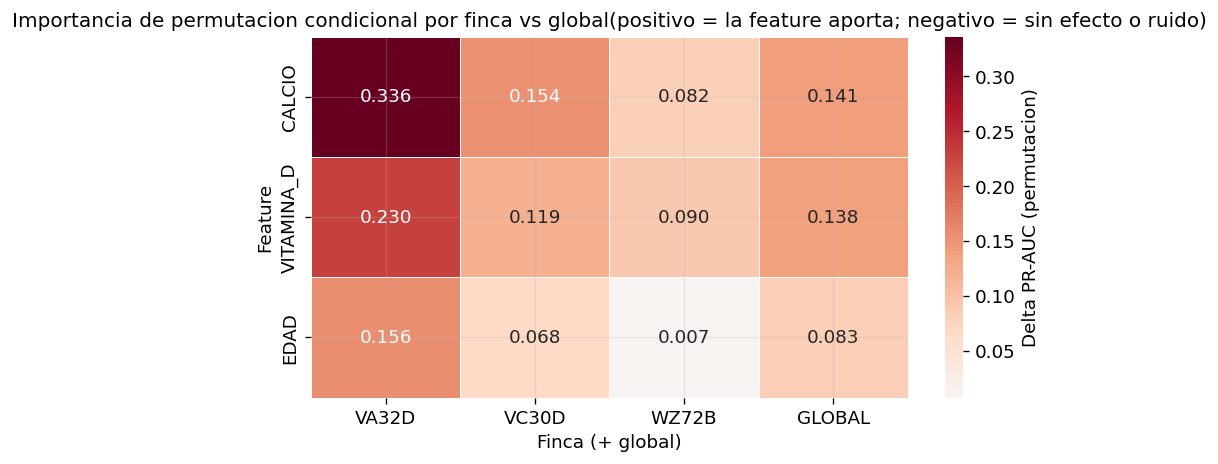

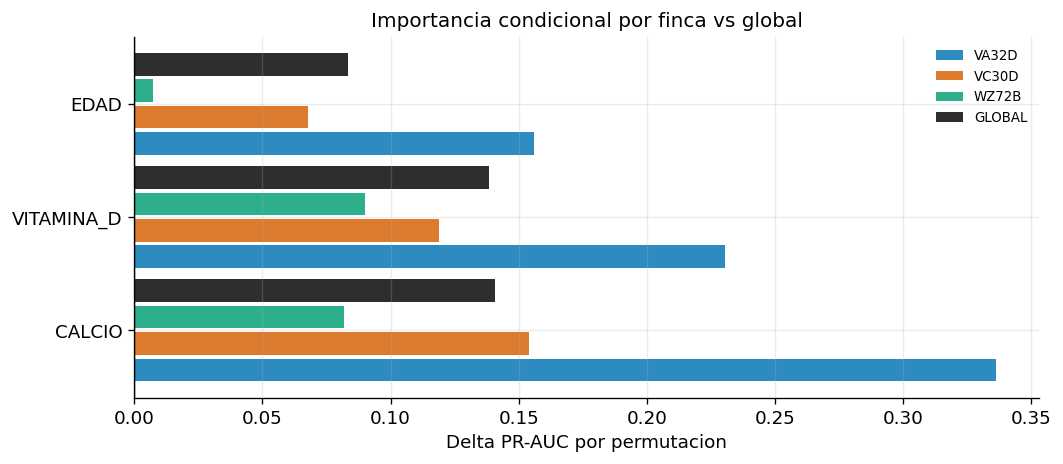

In [10]:
# Heatmap: importancia por feature x finca (+ columna global)
farms_ok  = list(farm_imp.keys())
feat_order = sorted(global_imp.keys(), key=lambda f: -global_imp[f][0])

data_heat = pd.DataFrame(index=feat_order, columns=farms_ok + ["GLOBAL"])
for feat in feat_order:
    for farm in farms_ok:
        data_heat.loc[feat, farm] = round(farm_imp[farm][feat][0], 4)
    data_heat.loc[feat, "GLOBAL"] = round(global_imp[feat][0], 4)

data_heat = data_heat.astype(float)

fig, ax = plt.subplots(figsize=(max(7, len(farms_ok) + 3), max(4, len(feat_order) * 0.8)))
sns.heatmap(data_heat, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Delta PR-AUC (permutacion)"})
ax.set_title("Importancia de permutacion condicional por finca vs global(positivo = la feature aporta; negativo = sin efecto o ruido)")
ax.set_ylabel("Feature")
ax.set_xlabel("Finca (+ global)")
plt.tight_layout()
plt.savefig("figures/fig_06c_heatmap_imp_condicional.png", dpi=150, bbox_inches="tight")
plt.show()

# Barplot comparativo
fig, ax = plt.subplots(figsize=(9, max(4, len(feat_order) * 0.7)))
y_pos = np.arange(len(feat_order))
width = 0.8 / (len(farms_ok) + 1)
offsets = np.linspace(-0.35, 0.35, len(farms_ok) + 1)
all_cols = list(EXPL_PAL.values())[:len(farms_ok)] + ["black"]
all_labels = farms_ok + ["GLOBAL"]

for j, (farm_j, col_j) in enumerate(zip(all_labels, all_cols)):
    means_j = [data_heat.loc[f, farm_j] for f in feat_order]
    ax.barh(y_pos + offsets[j], means_j, height=width,
            color=col_j, alpha=0.82, label=farm_j)

ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(feat_order)
ax.set_xlabel("Delta PR-AUC por permutacion")
ax.set_title("Importancia condicional por finca vs global")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/fig_06c_barplot_imp_condicional.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. SHAP global y agrupado por finca

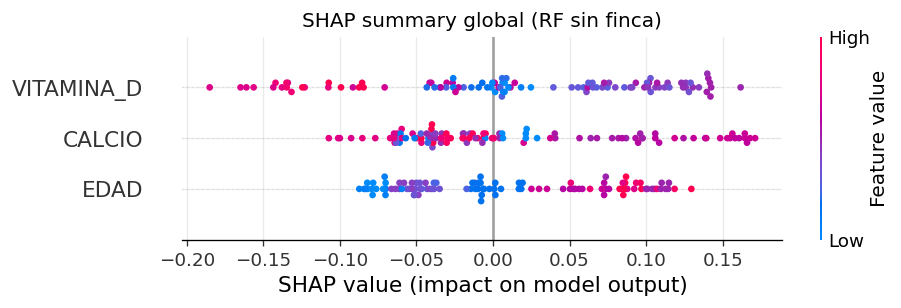

In [11]:
prep  = FINAL.named_steps["prep"]
clf   = FINAL.named_steps["clf"]
Xt    = prep.transform(Xs)
names = list(prep.get_feature_names_out())

explainer = shap.TreeExplainer(clf)
sv_raw    = explainer.shap_values(Xt)
if isinstance(sv_raw, list):
    sv = sv_raw[1]
elif np.asarray(sv_raw).ndim == 3:
    sv = np.asarray(sv_raw)[:, :, 1]
else:
    sv = np.asarray(sv_raw)
exp_val = (float(explainer.expected_value[1])
           if isinstance(explainer.expected_value, (list, np.ndarray))
           else float(explainer.expected_value))

plt.figure(figsize=(9, max(4, 0.5 * len(names))))
shap.summary_plot(sv, Xt, feature_names=names, show=False, max_display=len(names))
plt.title("SHAP summary global (RF sin finca)")
plt.tight_layout()
plt.savefig("figures/fig_06c_shap_global.png", dpi=150, bbox_inches="tight")
plt.show()


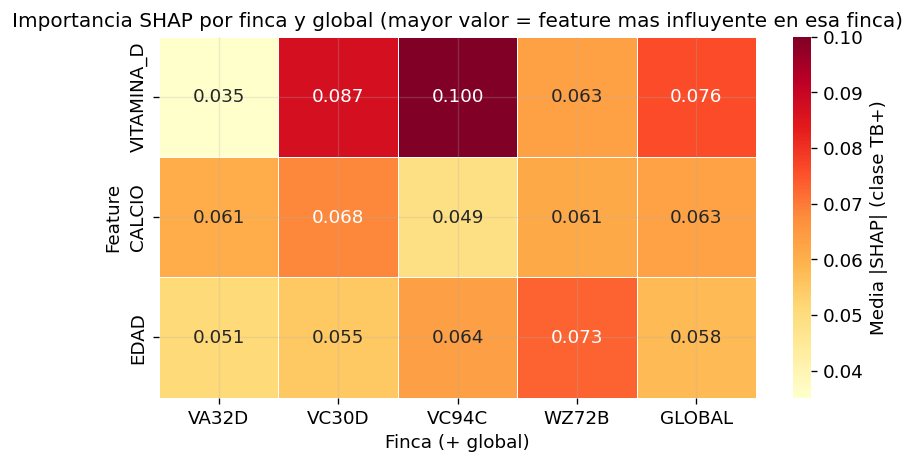

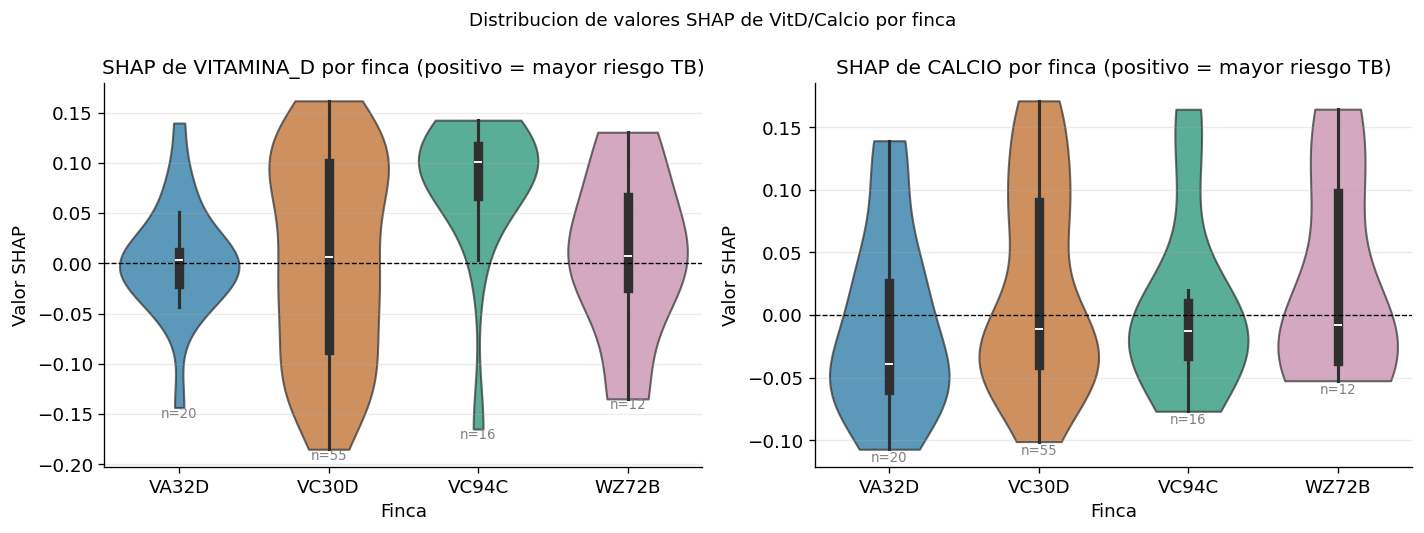

In [12]:
# Media |SHAP| por feature dentro de cada finca
shap_farm = {}
for farm in EXPLOTS:
    mask_f = g == farm
    shap_farm[farm] = np.abs(sv[mask_f]).mean(axis=0)

shap_heat = pd.DataFrame(
    {farm: shap_farm[farm] for farm in EXPLOTS},
    index=names,
)
shap_heat["GLOBAL"] = np.abs(sv).mean(axis=0)
shap_heat = shap_heat.sort_values("GLOBAL", ascending=False)

fig, ax = plt.subplots(figsize=(max(7, len(EXPLOTS) + 2), max(4, len(names) * 0.8)))
sns.heatmap(shap_heat, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Media |SHAP| (clase TB+)"})
ax.set_title("Importancia SHAP por finca y global (mayor valor = feature mas influyente en esa finca)")
ax.set_xlabel("Finca (+ global)"); ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/fig_06c_shap_por_finca.png", dpi=150, bbox_inches="tight")
plt.show()

# Violinplot: distribucion de valores SHAP de VitD/Calcio por finca
vitd_idx  = names.index("VITAMINA_D") if "VITAMINA_D" in names else None
calcio_idx = names.index("CALCIO")    if "CALCIO"    in names else None
feat_idx   = [(n, i) for n, i in [("VITAMINA_D", vitd_idx), ("CALCIO", calcio_idx)]
              if i is not None]

if feat_idx:
    fig, axes_v = plt.subplots(1, len(feat_idx), figsize=(6 * len(feat_idx), 4.5))
    if len(feat_idx) == 1: axes_v = [axes_v]
    for ax_v, (feat_name, fi) in zip(axes_v, feat_idx):
        df_shap = pd.DataFrame({
            "SHAP": sv[:, fi],
            "Finca": g,
            "TB": ["TB+" if yi == 1 else "TB-" for yi in y],
        })
        sns.violinplot(data=df_shap, x="Finca", y="SHAP", order=EXPLOTS,
                       palette=EXPL_PAL, inner="box", ax=ax_v, alpha=0.7, cut=0)
        ax_v.axhline(0, color="black", lw=0.8, ls="--")
        ax_v.set_title(f"SHAP de {feat_name} por finca (positivo = mayor riesgo TB)")
        ax_v.set_xlabel("Finca"); ax_v.set_ylabel("Valor SHAP")
        for i_f, farm in enumerate(EXPLOTS):
            n_f = (g == farm).sum()
            ax_v.text(i_f, df_shap[df_shap.Finca == farm].SHAP.min() - 0.01,
                      f"n={n_f}", ha="center", fontsize=8, color="grey")
    plt.suptitle("Distribucion de valores SHAP de VitD/Calcio por finca", fontsize=11)
    plt.tight_layout()
    plt.savefig("figures/fig_06c_shap_violin_finca.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5. PDP + ICE condicionados a finca

**ICE (Individual Conditional Expectation):** una curva por animal que muestra como
cambia P(TB+) al variar VitD manteniendo el resto constante. Las lineas coloreadas
por finca revelan si los animales de una finca siguen trayectorias distintas.

**PDP por finca:** media de las curvas ICE dentro de cada finca — indica la tendencia
promedio intra-finca, sin el ruido individual.

Interpretacion:
- Lineas de todas las fincas con la misma pendiente → efecto universal de VitD.
- Pendiente opuesta entre fincas → interaccion finca x VitD.
- Curvas planas → VitD no cambia la prediccion dentro de la finca.


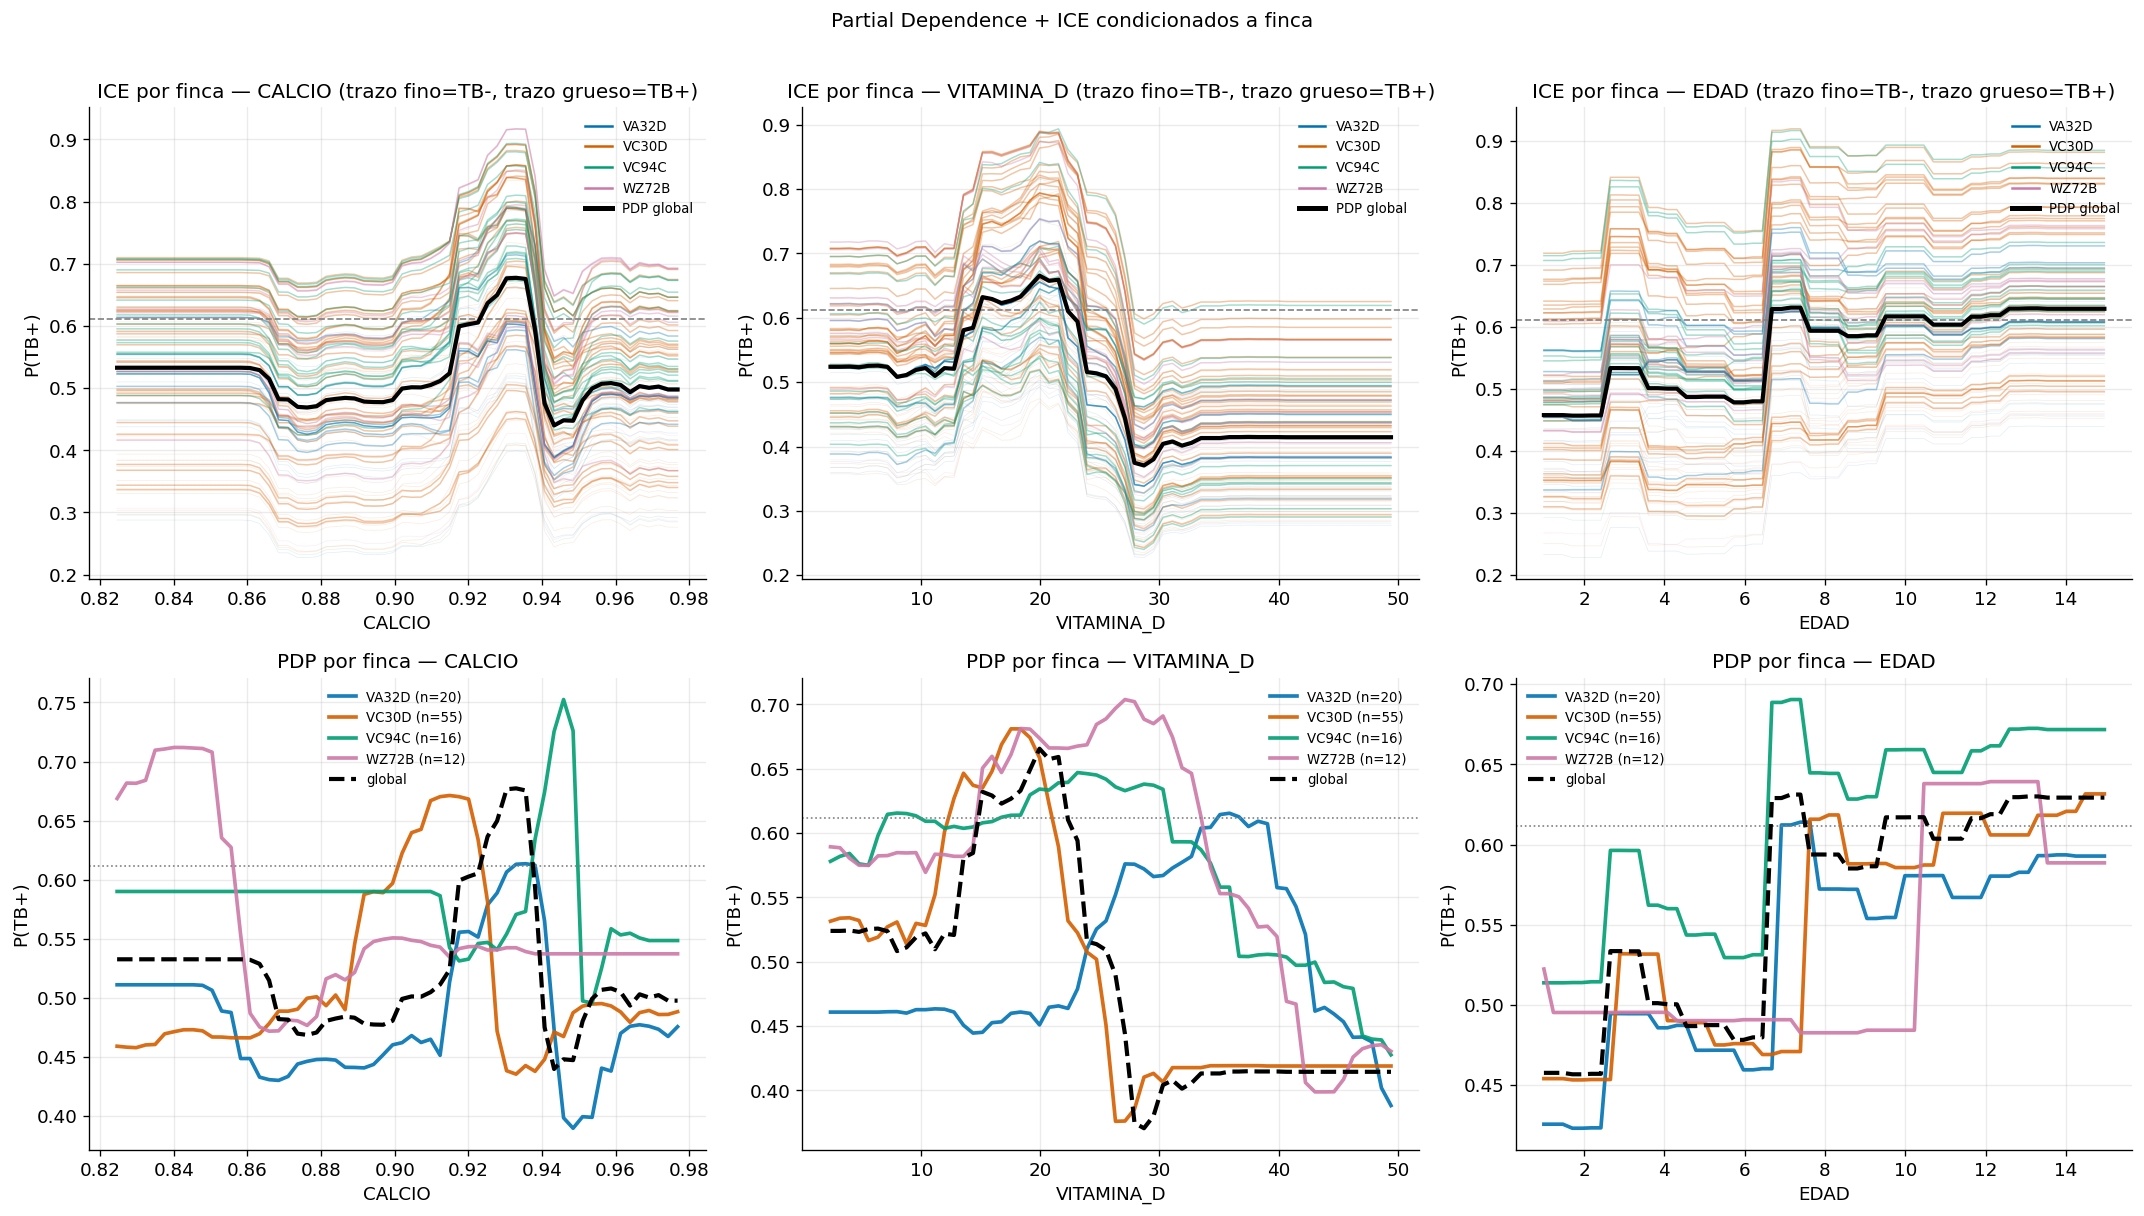

In [20]:
CONT_SEL = [f for f in SELECTED if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_SEL:
    CONT_SEL = [f for f in SELECTED if f in tb.NUM_FEATURES]

def ice_pdp_curves(model, X, feat, n_grid=60):
    lo = float(X[feat].quantile(0.02))
    hi = float(X[feat].quantile(0.98))
    grid = np.linspace(lo, hi, n_grid)
    Xc = X.reset_index(drop=True).copy()
    ice = np.zeros((len(Xc), n_grid))
    for j, val in enumerate(grid):
        Xc[feat] = val
        ice[:, j] = model.predict_proba(Xc)[:, 1]
    return grid, ice, ice.mean(axis=0)

if CONT_SEL:
    n_feat = len(CONT_SEL)
    fig, axes_ice = plt.subplots(2, n_feat, figsize=(6 * n_feat, 10),
                                  squeeze=False)

    for ci, feat in enumerate(CONT_SEL):
        grid, ice_mat, pdp_g = ice_pdp_curves(FINAL, Xs, feat)

        # --- Fila 0: ICE global coloreado por finca ---
        ax0 = axes_ice[0][ci]
        for ii in range(len(ice_mat)):
            farm_i = g[ii]
            col_i  = EXPL_PAL.get(farm_i, "grey")
            lw_i   = 0.4 if y[ii] == 0 else 0.9
            al_i   = 0.12 if y[ii] == 0 else 0.35
            ax0.plot(grid, ice_mat[ii], lw=lw_i, alpha=al_i, color=col_i)
        ax0.plot(grid, pdp_g, color="black", lw=2.5, zorder=10, label="PDP global")
        ax0.axhline(y.mean(), color="grey", ls="--", lw=1, label="prevalencia")
        ax0.set_title(f"ICE por finca — {feat} (trazo fino=TB-, trazo grueso=TB+)")
        ax0.set_xlabel(feat); ax0.set_ylabel("P(TB+)")
        legend_h = [plt.Line2D([0], [0], color=c, lw=1.5, label=f)
                    for f, c in EXPL_PAL.items()]
        legend_h += [plt.Line2D([0], [0], color="black", lw=3, label="PDP global")]
        ax0.legend(handles=legend_h, fontsize=8, loc="upper right")

        # --- Fila 1: PDP medio por finca ---
        ax1 = axes_ice[1][ci]
        for farm, col_f in EXPL_PAL.items():
            mask_f = g == farm
            n_f = mask_f.sum()
            if n_f < 5: continue
            Xf = Xs[mask_f].reset_index(drop=True)
            _, _, pdp_farm = ice_pdp_curves(FINAL, Xf, feat)
            ax1.plot(grid, pdp_farm, color=col_f, lw=2.2, alpha=0.9,
                     label=f"{farm} (n={n_f})")
        ax1.plot(grid, pdp_g, color="black", lw=2.5, ls="--", label="global", zorder=10)
        ax1.axhline(y.mean(), color="grey", ls=":", lw=1)
        ax1.set_title(f"PDP por finca — {feat}")
        ax1.set_xlabel(feat); ax1.set_ylabel("P(TB+)")
        ax1.legend(fontsize=8)

    plt.suptitle("Partial Dependence + ICE condicionados a finca", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig("figures/fig_06c_ice_pdp.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No hay features continuas en SELECTED para PDP/ICE.")


## 6. ALE — Accumulated Local Effects global y por finca

El ALE es preferible al PDP cuando hay correlacion entre predictores (que aqui
esperamos, porque finca correlaciona con VitD). El ALE calcula el efecto **local**
de cada feature promediando diferencias dentro de intervalos estrechos, sin
extrapolar fuera de la distribucion observada.

- **Curva negra:** ALE global (todos los animales).
- **Curvas de colores:** ALE calculado solo con los animales de cada finca.

Interpretacion:
- Si el ALE global y los ALE de finca son similares → el efecto de VitD es
  consistente entre fincas.
- Si el ALE de finca es plano pero el global tiene pendiente → la senal global
  viene del efecto entre fincas, no dentro de ellas.


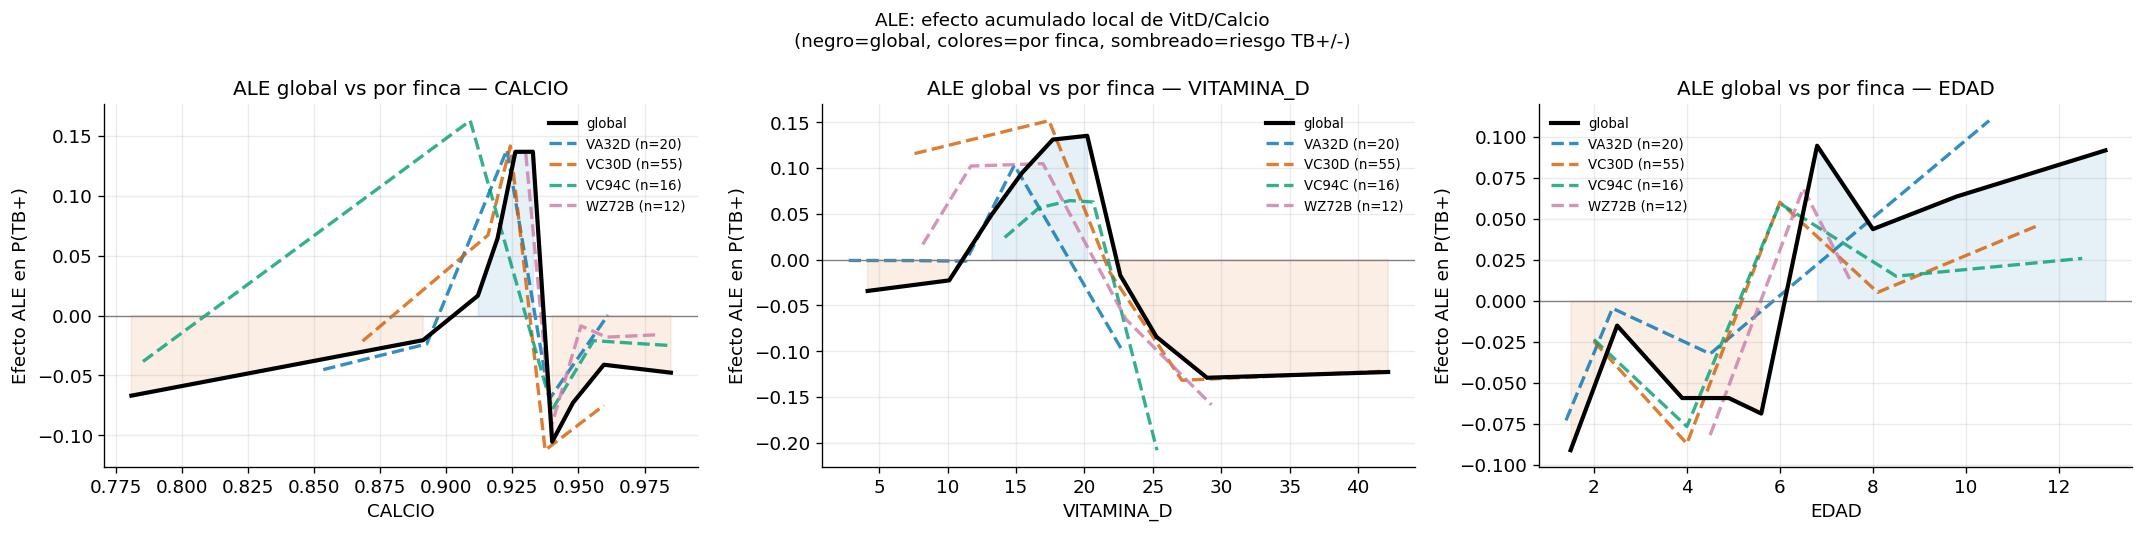

In [21]:
def ale_1d(model, X, feat, bins=8):
    x = X[feat].dropna().values
    q = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(q) < 3:
        return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for ii in range(len(q) - 1):
        mask_b = (X[feat] >= q[ii]) & (X[feat] <= q[ii + 1])
        if not mask_b.any():
            eff.append(0.0); continue
        Xl = Xc.loc[mask_b].copy(); Xl[feat] = q[ii]
        Xh = Xc.loc[mask_b].copy(); Xh[feat] = q[ii + 1]
        eff.append((model.predict_proba(Xh)[:, 1]
                    - model.predict_proba(Xl)[:, 1]).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_SEL:
    n_feat = len(CONT_SEL)
    fig, axes_ale = plt.subplots(1, n_feat, figsize=(6 * n_feat, 4.5),
                                  squeeze=False)

    for ci, feat in enumerate(CONT_SEL):
        ax = axes_ale[0][ci]

        # ALE global
        cx_g, ale_g = ale_1d(FINAL, Xs, feat, bins=10)
        if len(cx_g):
            ax.fill_between(cx_g, 0, ale_g, where=(ale_g > 0),
                            alpha=0.10, color=PALETTE[0])
            ax.fill_between(cx_g, 0, ale_g, where=(ale_g < 0),
                            alpha=0.10, color=PALETTE[1])
            ax.plot(cx_g, ale_g, color="black", lw=2.5, zorder=10, label="global")

        # ALE por finca
        for farm, col_f in EXPL_PAL.items():
            mask_f = g == farm
            n_f = mask_f.sum()
            if n_f < 8: continue
            Xf = Xs[mask_f].reset_index(drop=True)
            cx_f, ale_f = ale_1d(FINAL, Xf, feat, bins=5)
            if len(cx_f):
                ax.plot(cx_f, ale_f, color=col_f, lw=2, alpha=0.8,
                        ls="--", label=f"{farm} (n={n_f})")

        ax.axhline(0, color="grey", lw=0.8)
        ax.set_title(f"ALE global vs por finca — {feat}")
        ax.set_xlabel(feat); ax.set_ylabel("Efecto ALE en P(TB+)")
        ax.legend(fontsize=8)

    plt.suptitle(
        "ALE: efecto acumulado local de VitD/Calcio\n"
        "(negro=global, colores=por finca, sombreado=riesgo TB+/-)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig("figures/fig_06c_ale_farm.png", dpi=150, bbox_inches="tight")
    plt.show()


## 7. SHAP dependence condicionado a finca

Los SHAP dependence plots muestran la relacion entre el **valor de la feature** y
su **valor SHAP** (contribucion a la prediccion de TB+). Colorear por finca permite ver:

- Si la nube de puntos de cada finca ocupa regiones distintas → VitD difiere entre fincas.
- Si la pendiente OLS dentro de cada finca es similar → el efecto individual es consistente.
- Si la pendiente intra-finca es plana → VitD no contribuye al modelo una vez fijada la finca.

La tabla de pendientes (b) al final de la celda es el resumen mas directo:
`b < 0` significa mas VitD → SHAP mas negativo → el modelo predice menos TB.


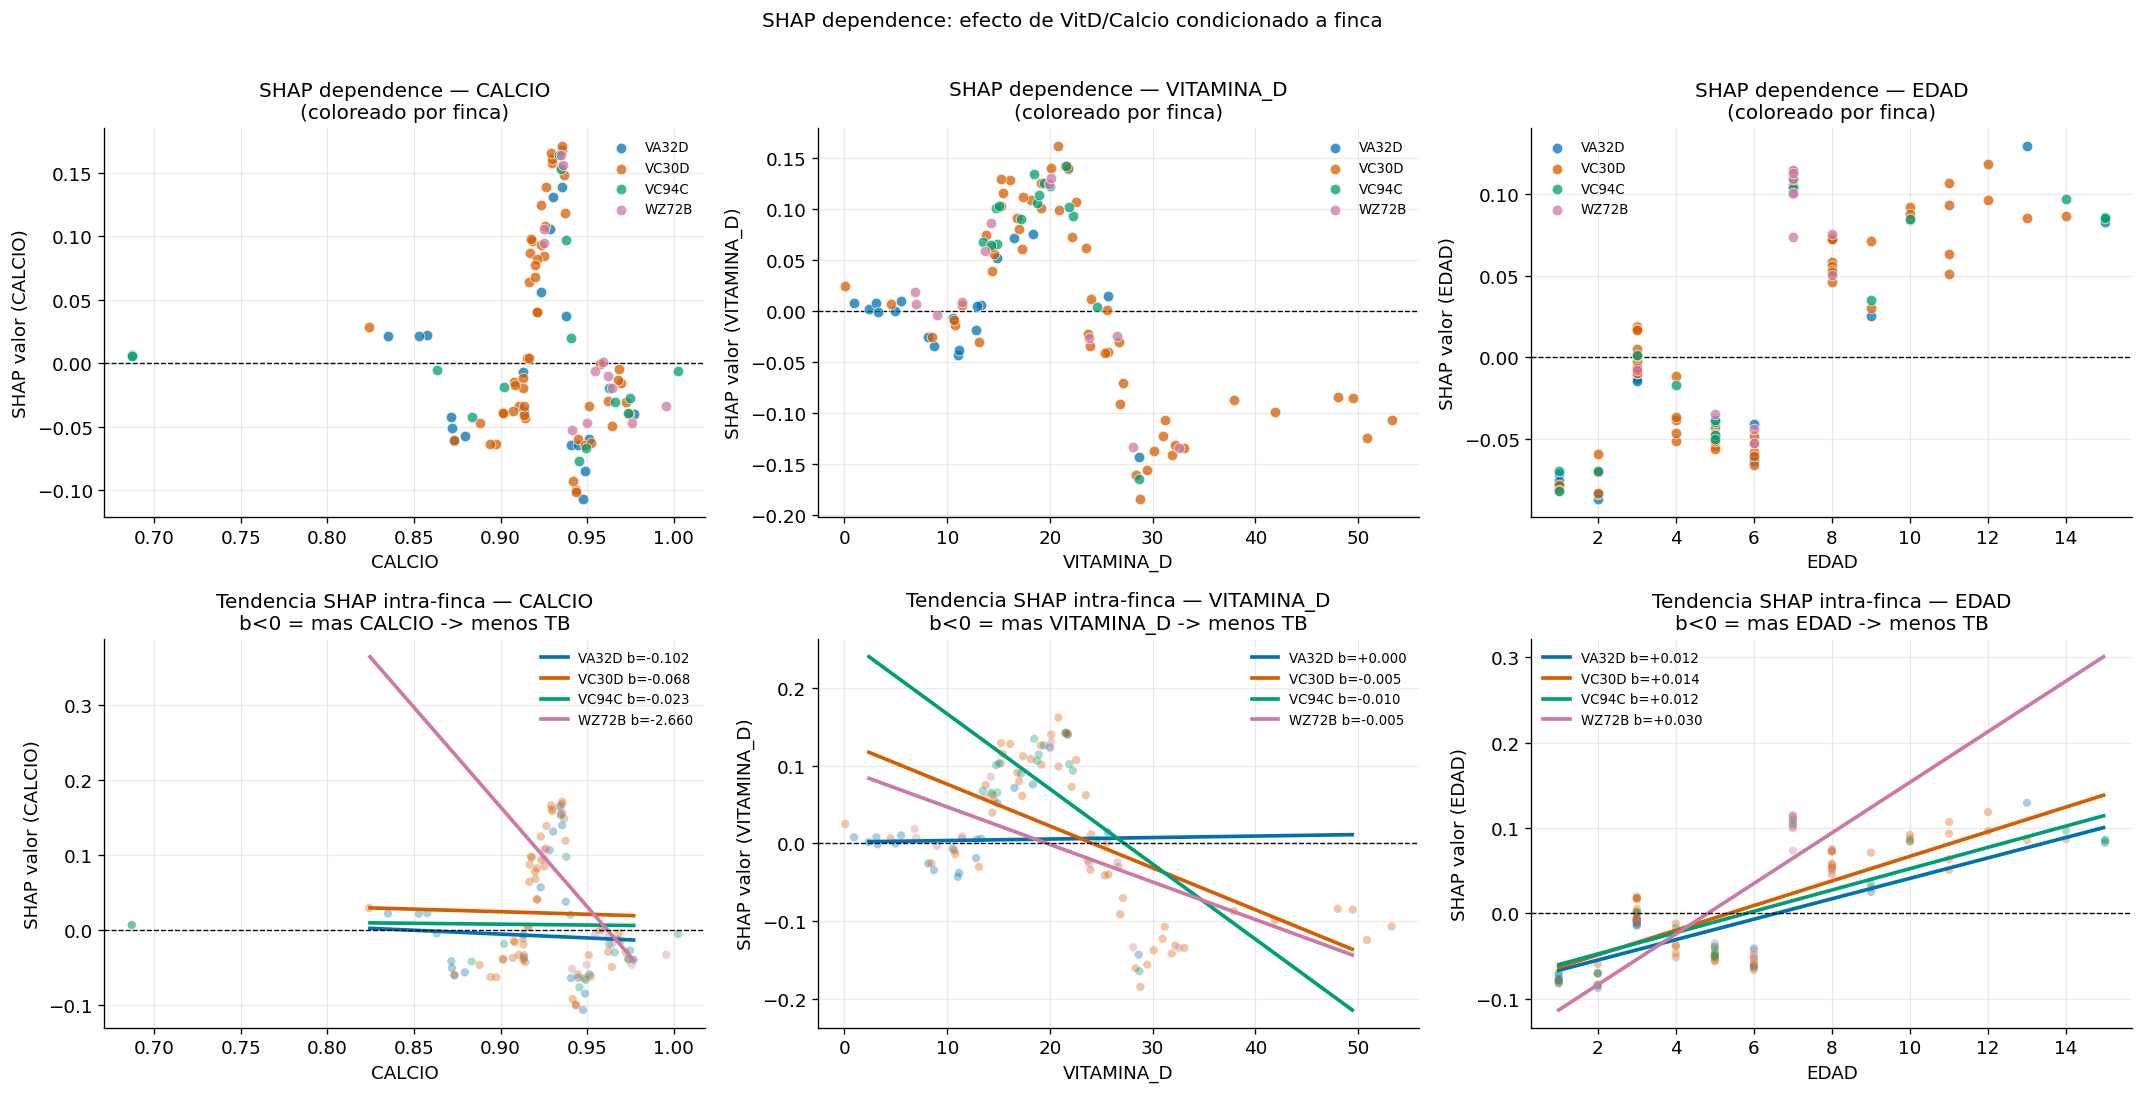

Pendiente SHAP intra-finca (b, OLS) por feature y finca:
  b < 0: mas valor -> SHAP mas negativo -> el modelo ve menos riesgo TB
  b ~ 0: VitD/Calcio no cambia la prediccion dentro de esa finca

  CALCIO:
    VA32D (n=20): b=-0.1024  [protector (b<0)]
    VC30D (n=55): b=-0.0683  [protector (b<0)]
    VC94C (n=16): b=-0.0229  [protector (b<0)]
    WZ72B (n=12): b=-2.6603  [protector (b<0)]
  VITAMINA_D:
    VA32D (n=20): b=+0.0002  [neutro]
    VC30D (n=55): b=-0.0054  [protector (b<0)]
    VC94C (n=16): b=-0.0097  [protector (b<0)]
    WZ72B (n=12): b=-0.0048  [protector (b<0)]
  EDAD:
    VA32D (n=20): b=+0.0120  [riesgo (b>0)]
    VC30D (n=55): b=+0.0144  [riesgo (b>0)]
    VC94C (n=16): b=+0.0125  [riesgo (b>0)]
    WZ72B (n=12): b=+0.0297  [riesgo (b>0)]


In [19]:
# Mapear nombres originales a columnas de sv (que usa nombres de preprocesador)
def get_shap_col(feat, names):
    if feat in names: return names.index(feat)
    for i, n in enumerate(names):
        if n.endswith("__" + feat) or n == feat:
            return i
    return None

feat_to_shap = {f: get_shap_col(f, names) for f in CONT_SEL}
CONT_SHAP = [f for f in CONT_SEL if feat_to_shap[f] is not None]

if CONT_SHAP:
    n_feat = len(CONT_SHAP)
    fig, axes_dep = plt.subplots(2, n_feat, figsize=(6 * n_feat, 9),
                                  squeeze=False)

    for ci, feat in enumerate(CONT_SHAP):
        fi   = feat_to_shap[feat]
        xval = Xs[feat].values
        sval = sv[:, fi]

        # --- Fila 0: scatter por finca ---
        ax0 = axes_dep[0][ci]
        for farm, col_f in EXPL_PAL.items():
            mask_f = g == farm
            ax0.scatter(xval[mask_f], sval[mask_f], color=col_f, label=farm,
                        alpha=0.75, s=40, edgecolors="white", lw=0.5, zorder=3)
        ax0.axhline(0, color="black", lw=0.8, ls="--")
        ax0.set_title(f"SHAP dependence — {feat}\n(coloreado por finca)")
        ax0.set_xlabel(feat); ax0.set_ylabel(f"SHAP valor ({feat})")
        ax0.legend(fontsize=8)

        # --- Fila 1: tendencia OLS intra-finca ---
        ax1 = axes_dep[1][ci]
        x_lo = float(np.nanpercentile(xval, 2))
        x_hi = float(np.nanpercentile(xval, 98))
        x_fit = np.linspace(x_lo, x_hi, 100)
        slopes_summary = {}

        for farm, col_f in EXPL_PAL.items():
            mask_f = g == farm
            xf = xval[mask_f]; sf = sval[mask_f]
            ok = np.isfinite(xf) & np.isfinite(sf)
            if ok.sum() < 4:
                slopes_summary[farm] = np.nan; continue
            ax1.scatter(xf[ok], sf[ok], color=col_f, alpha=0.35, s=25,
                        edgecolors="none")
            p = np.polyfit(xf[ok], sf[ok], 1)
            slopes_summary[farm] = round(float(p[0]), 4)
            ax1.plot(x_fit, np.polyval(p, x_fit), color=col_f, lw=2.2,
                     label=f"{farm} b={p[0]:+.3f}")

        ax1.axhline(0, color="black", lw=0.8, ls="--")
        ax1.set_title(f"Tendencia SHAP intra-finca — {feat}\nb<0 = mas {feat} -> menos TB")
        ax1.set_xlabel(feat); ax1.set_ylabel(f"SHAP valor ({feat})")
        ax1.legend(fontsize=8)

    plt.suptitle("SHAP dependence: efecto de VitD/Calcio condicionado a finca",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig("figures/fig_06c_shap_dep_finca.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Tabla de pendientes
    print("Pendiente SHAP intra-finca (b, OLS) por feature y finca:")
    print("  b < 0: mas valor -> SHAP mas negativo -> el modelo ve menos riesgo TB")
    print("  b ~ 0: VitD/Calcio no cambia la prediccion dentro de esa finca")
    print()
    for feat in CONT_SHAP:
        fi   = feat_to_shap[feat]
        xval = Xs[feat].values; sval = sv[:, fi]
        print(f"  {feat}:")
        for farm in EXPLOTS:
            mask_f = g == farm
            xf = xval[mask_f]; sf = sval[mask_f]
            ok = np.isfinite(xf) & np.isfinite(sf)
            if ok.sum() < 4:
                print(f"    {farm}: n insuficiente"); continue
            p = np.polyfit(xf[ok], sf[ok], 1)
            b = float(p[0])
            direction = "protector (b<0)" if b < -0.001 else (
                        "riesgo (b>0)" if b > 0.001 else "neutro")
            print(f"    {farm} (n={ok.sum()}): b={b:+.4f}  [{direction}]")
else:
    print("No hay features continuas seleccionadas con indice SHAP mapeado.")


## 8. Interpretacion consolidada

### Clave de lectura del heatmap de importancia condicional

| Patron | Interpretacion |
|---|---|
| Importancia alta en TODAS las fincas | VitD/Calcio predicen TB intra-finca en todas partes — efecto individual real y generalizable |
| Importancia alta solo en VC30D (n grande) | La senal es especifica de VC30D — puede ser efecto real o sesgo por tamano de muestra |
| Importancia alta globalmente, baja en todas las fincas | VitD/Calcio son proxies de la finca — no predicen TB individualmente |
| Importancia negativa dentro de una finca | La permutacion MEJORA la prediccion en esa finca — la feature introduce ruido intra-finca |

### Interpretacion de SHAP por finca

- Si la distribucion de SHAP(VitD) es similar entre fincas → efecto universal.
- Si difiere drasticamente (ej. positivo en VC30D, negativo en WZ72B) → interaccion finca x VitD.

### Comparacion de los tres enfoques (06a, 06b, 06c)

| Enfoque | Pregunta central | Limitacion |
|---|---|---|
| 06a Residualizacion | ¿VitD individual predice TB? | El RF no separa bien efecto finca vs. individuo |
| 06b GLMM | ¿Cual es el OR de VitD ajustado por finca? | n=103 y 4 fincas limita la estimacion del efecto aleatorio |
| 06c Importancia condicional | ¿VitD aporta dentro de cada finca? | n por finca muy pequeno (14-55) para permutacion estable |
